In [20]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
beef_url = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/csv-export-2026-04-13.csv"
pollution_url = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/FAOSTAT_data_en_4-13-2026.csv"
beef = pd.read_csv(beef_url)
pollution = pd.read_csv(pollution_url)
#beef.head()
#pollution.head()

In [5]:
import matplotlib.pyplot as plt

In [6]:
#beef
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

beef['BeefPrice'] = beef[months].mean(axis=1)

beef = beef[['Year', 'BeefPrice']]

beef.head()

,Year,BeefPrice
0,1984,1.287167
1,1985,1.237500
2,1986,1.232000
3,1987,1.309917
4,1988,1.364750


In [8]:
pollution = pollution[['Year', 'Value']]

pollution = pollution.rename(columns={'Value': 'Emissions'})

pollution.head()

,Year,Emissions
0,1961,6876.7867
1,1962,6980.1400
2,1963,7136.3680
3,1964,7251.5884
4,1965,7253.3471


In [10]:
merged = pd.merge(beef, pollution, on='Year', how='inner')

merged.head()

,Year,BeefPrice,Emissions
0,1984,1.287167,7094.6320
1,1985,1.237500,6899.2465
2,1986,1.232000,6654.7280
3,1987,1.309917,6446.5550
4,1988,1.364750,6316.8100


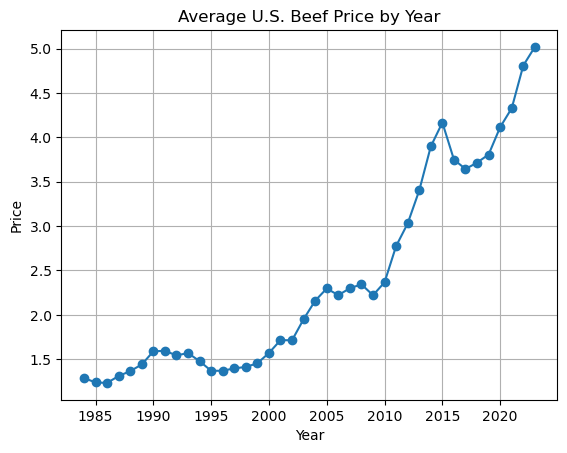

In [11]:
plt.figure()
plt.plot(merged['Year'], merged['BeefPrice'], marker='o')
plt.title('Average U.S. Beef Price by Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()
plt.show()


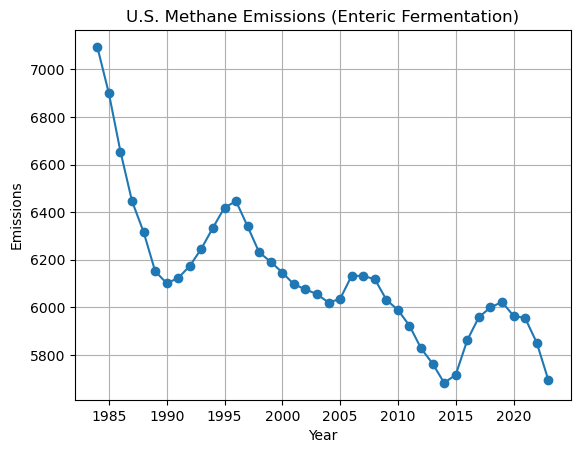

In [12]:
plt.figure()
plt.plot(merged['Year'], merged['Emissions'], marker='o')
plt.title('U.S. Methane Emissions (Enteric Fermentation)')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.grid()
plt.show()

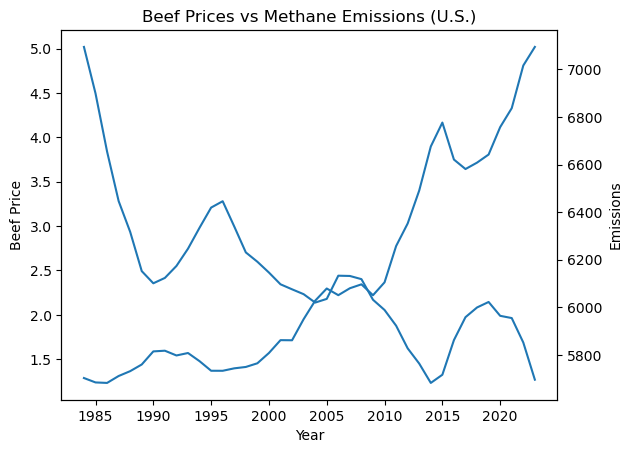

In [13]:
fig, ax1 = plt.subplots()

ax1.plot(merged['Year'], merged['BeefPrice'])
ax1.set_xlabel('Year')
ax1.set_ylabel('Beef Price')

ax2 = ax1.twinx()
ax2.plot(merged['Year'], merged['Emissions'])
ax2.set_ylabel('Emissions')

plt.title('Beef Prices vs Methane Emissions (U.S.)')
plt.show()

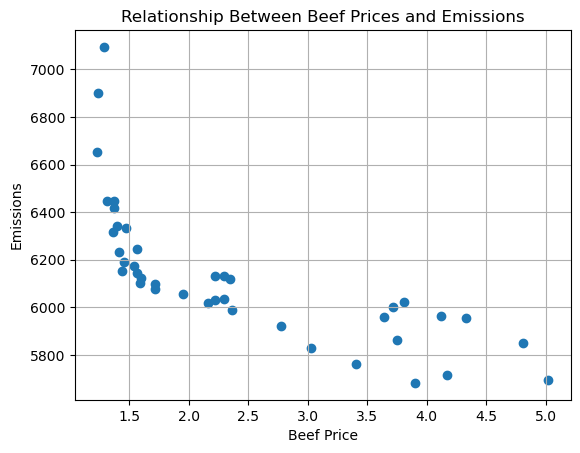

In [14]:
plt.figure()
plt.scatter(merged['BeefPrice'], merged['Emissions'])
plt.xlabel('Beef Price')
plt.ylabel('Emissions')
plt.title('Relationship Between Beef Prices and Emissions')
plt.grid()
plt.show()

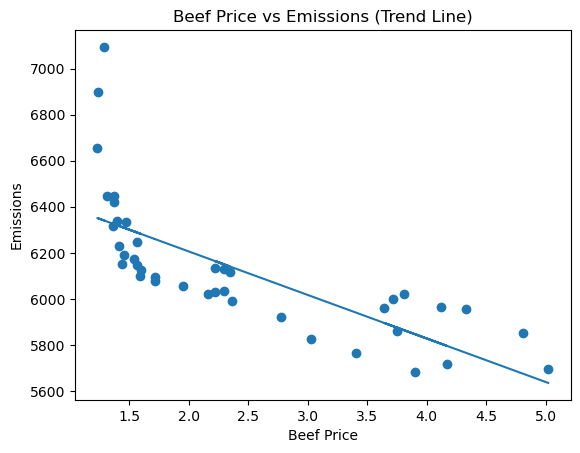

In [17]:
x = merged['BeefPrice']
y = merged['Emissions']

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel('Beef Price')
plt.ylabel('Emissions')
plt.title('Beef Price vs Emissions (Trend Line)')
plt.show()

In [21]:
r, p = pearsonr(merged['BeefPrice'], merged['Emissions'])

print("r:", r)
print("p-value:", p)

r: -0.7341412168115732
p-value: 7.00691782285512e-08


In [23]:
cpi_url = "https://raw.githubusercontent.com/JackSmoot/DS256/refs/heads/main/Inflation.csv"
cpi = pd.read_csv(cpi_url)
cpi.head()

,Year,Annual
0,1960,29.6
1,1961,29.9
2,1962,30.2
3,1963,30.6
4,1964,31.0


In [26]:
cpi = cpi.rename(columns={'Annual': 'CPI'})
cpi = cpi[['Year', 'CPI']]

cpi.head()
merged = pd.merge(merged, cpi, on='Year', how='inner')

merged[['Year', 'BeefPrice', 'CPI']].head()
base_cpi = merged['CPI'].iloc[-1]

merged['RealBeefPrice'] = merged['BeefPrice'] * (base_cpi / merged['CPI'])

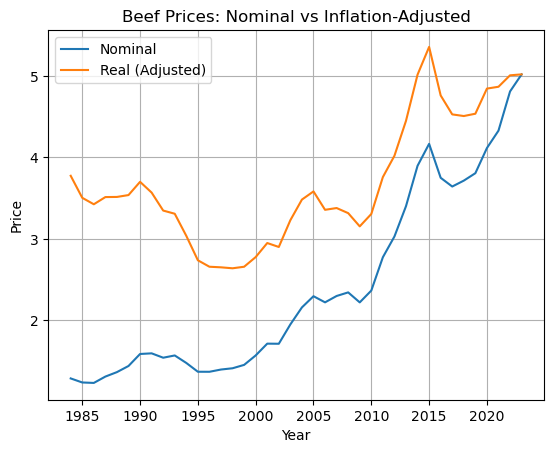

In [27]:
plt.figure()
plt.plot(merged['Year'], merged['BeefPrice'], label='Nominal')
plt.plot(merged['Year'], merged['RealBeefPrice'], label='Real (Adjusted)')
plt.legend()
plt.title('Beef Prices: Nominal vs Inflation-Adjusted')
plt.xlabel('Year')
plt.ylabel('Price')
plt.grid()
plt.show()

In [28]:
r_nominal = merged['BeefPrice'].corr(merged['Emissions'])

r_real = merged['RealBeefPrice'].corr(merged['Emissions'])

print("Nominal r:", r_nominal)
print("Real r:", r_real)

Nominal r: -0.7341412168115731
Real r: -0.5437928463025177


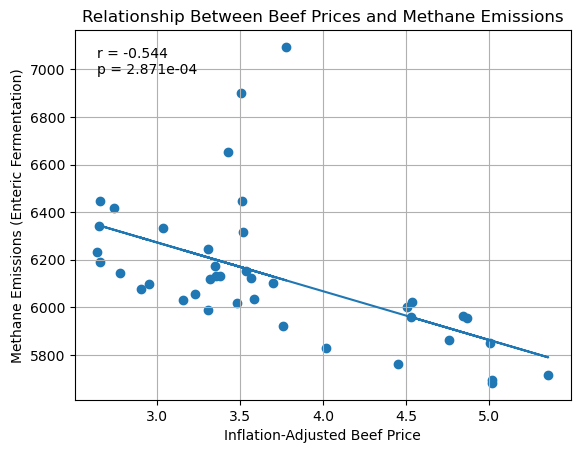

In [29]:
# Data
x = merged['RealBeefPrice']
y = merged['Emissions']

# Correlation + p-value
r, p = pearsonr(x, y)

# Line of best fit
m, b = np.polyfit(x, y, 1)

# Create plot
plt.figure()

# Scatter
plt.scatter(x, y)

# Best fit line
plt.plot(x, m*x + b)

# Labels and title
plt.xlabel('Inflation-Adjusted Beef Price')
plt.ylabel('Methane Emissions (Enteric Fermentation)')
plt.title('Relationship Between Beef Prices and Methane Emissions')

# Annotation box (this is key)
plt.text(
    x.min(),
    y.max(),
    f'r = {r:.3f}\np = {p:.3e}',
    verticalalignment='top'
)

# Grid for readability
plt.grid()

plt.show()